<a href="https://colab.research.google.com/github/edu-delahoz/edu.estructuraDB/blob/main/laboratorioQuadTree21Abril.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Quadtree vs Fuerza Bruta
**Sistema de logística de entregas en una ciudad**

## README

### Descripción
Implementación de un Quadtree generalizado para K dimensiones, aplicado a un sistema de logística con 10,000 puntos de entrega en una ciudad de 10km × 10km.

### ¿Qué es un Quadtree?
Un Quadtree es una estructura de datos que divide el espacio en regiones. En 2D, cada nodo se divide en **4 cuadrantes** (de ahí el nombre "Quad"). En K dimensiones se generaliza a **2^K hijos** por nodo. Cada nodo tiene una capacidad máxima de puntos; cuando se supera, el nodo se subdivide.

### Diferencia con KD-Tree
- **KD-Tree**: divide el espacio con un corte a la vez (alternando dimensiones), creando 2 hijos por nodo.
- **Quadtree**: divide el espacio en todas las dimensiones a la vez, creando 2^K hijos por nodo.

### Operaciones implementadas
- **Búsqueda por radio**: ¿Qué puntos de entrega están a 500 metros de un punto dado?
- **Vecino más cercano**: ¿Cuál es el punto de entrega más cercano a una ubicación dada?

### Estructura del notebook
1. Generación de datos e implementación del Quadtree
2. Ejecución y comparación de tiempos
3. Pruebas unitarias, visualizaciones y análisis
4. Métricas de rendimiento y discusión de resultados
5. Pregunta: ¿Para qué tamaño de datos el Quadtree comienza a ser más rápido?

## 1. Generación de datos e implementación

In [1]:
import random
import math
import time
import matplotlib.pyplot as plt
from itertools import product

# ============================================================
# 1. GENERACION DE DATOS (10,000 puntos en una ciudad ficticia)
#    Coordenadas en metros, ciudad de 10km x 10km
# ============================================================
random.seed(42)
NUM_PUNTOS = 10_000
K = 2  # numero de dimensiones
puntos = [tuple(random.uniform(0, 10000) for _ in range(K)) for _ in range(NUM_PUNTOS)]


# ============================================================
# 2. QUADTREE DESDE CERO (funciona para K dimensiones)
# ============================================================
class Limite:
    def __init__(self, centro, mitad):
        self.centro = centro
        self.mitad = mitad

    def contiene(self, punto):
        for i in range(len(self.centro)):
            if not (self.centro[i] - self.mitad[i] <= punto[i] <= self.centro[i] + self.mitad[i]):
                return False
        return True

    def intersecta_circulo(self, centro_circulo, radio):
        dist_cuadrada = 0
        for i in range(len(self.centro)):
            cercano = max(self.centro[i] - self.mitad[i],
                         min(centro_circulo[i], self.centro[i] + self.mitad[i]))
            dist_cuadrada += (centro_circulo[i] - cercano) ** 2
        return dist_cuadrada <= radio ** 2


class QuadTree:
    def __init__(self, limite, capacidad=4):
        self.limite = limite
        self.capacidad = capacidad
        self.puntos = []
        self.dividido = False
        self.hijos = []

    def insertar(self, punto):
        if not self.limite.contiene(punto):
            return False

        if len(self.puntos) < self.capacidad and not self.dividido:
            self.puntos.append(punto)
            return True

        if not self.dividido:
            self._subdividir()

        for hijo in self.hijos:
            if hijo.insertar(punto):
                return True
        return False

    def _subdividir(self):
        k = len(self.limite.centro)
        nueva_mitad = tuple(m / 2 for m in self.limite.mitad)

        for signos in product([-1, 1], repeat=k):
            nuevo_centro = tuple(
                self.limite.centro[i] + signos[i] * nueva_mitad[i]
                for i in range(k)
            )
            hijo = QuadTree(Limite(nuevo_centro, nueva_mitad), self.capacidad)
            self.hijos.append(hijo)

        for punto in self.puntos:
            for hijo in self.hijos:
                if hijo.insertar(punto):
                    break
        self.puntos = []
        self.dividido = True


def distancia(a, b):
    return math.sqrt(sum((ai - bi) ** 2 for ai, bi in zip(a, b)))


# ============================================================
# 3. BUSQUEDA POR RADIO (Range Search)
# ============================================================
def busqueda_radio_qt(nodo, centro, radio, resultados=None):
    if resultados is None:
        resultados = []

    if not nodo.limite.intersecta_circulo(centro, radio):
        return resultados

    for punto in nodo.puntos:
        if distancia(punto, centro) <= radio:
            resultados.append(punto)

    if nodo.dividido:
        for hijo in nodo.hijos:
            busqueda_radio_qt(hijo, centro, radio, resultados)

    return resultados


# ============================================================
# 4. VECINO MAS CERCANO
# ============================================================
def vecino_cercano_qt(nodo, objetivo, mejor=None, mejor_dist=float('inf')):
    if not nodo.limite.intersecta_circulo(objetivo, mejor_dist):
        return mejor, mejor_dist

    for punto in nodo.puntos:
        dist = distancia(punto, objetivo)
        if dist < mejor_dist:
            mejor = punto
            mejor_dist = dist

    if nodo.dividido:
        hijos_ordenados = sorted(nodo.hijos,
            key=lambda h: distancia(h.limite.centro, objetivo))
        for hijo in hijos_ordenados:
            mejor, mejor_dist = vecino_cercano_qt(hijo, objetivo, mejor, mejor_dist)

    return mejor, mejor_dist


# ============================================================
# 5. FUERZA BRUTA (para comparar)
# ============================================================
def busqueda_radio_bruta(puntos, centro, radio):
    return [p for p in puntos if distancia(p, centro) <= radio]


def vecino_cercano_bruto(puntos, objetivo):
    return min(puntos, key=lambda p: distancia(p, objetivo))

## 2. Ejecución y comparación de tiempos

In [2]:
# Construir quadtree
limite = Limite(
    centro=tuple(5000 for _ in range(K)),
    mitad=tuple(5000 for _ in range(K))
)

inicio = time.perf_counter()
arbol = QuadTree(limite, capacidad=4)
for p in puntos:
    arbol.insertar(p)
t_construccion = time.perf_counter() - inicio
print(f"QuadTree construido con {NUM_PUNTOS} puntos en {t_construccion:.4f}s")

# Punto de consulta y radio
centro = tuple(5000 for _ in range(K))
radio = 500
objetivo = (3200, 7800) if K == 2 else tuple(random.uniform(1000, 9000) for _ in range(K))

print(f"Centro de busqueda: {centro}")
print(f"Radio: {radio} metros")
print(f"Objetivo vecino cercano: {objetivo}")

# --- Busqueda por radio ---
print("\n--- BUSQUEDA POR RADIO ---")

inicio = time.perf_counter()
encontrados_qt = busqueda_radio_qt(arbol, centro, radio)
t_radio_qt = time.perf_counter() - inicio

inicio = time.perf_counter()
encontrados_bruta = busqueda_radio_bruta(puntos, centro, radio)
t_radio_bruta = time.perf_counter() - inicio

print(f"QuadTree:     {len(encontrados_qt)} puntos en {t_radio_qt:.6f}s")
print(f"Fuerza bruta: {len(encontrados_bruta)} puntos en {t_radio_bruta:.6f}s")
print(f"Speedup:      {t_radio_bruta / t_radio_qt:.1f}x mas rapido")

# --- Vecino mas cercano ---
print("\n--- VECINO MAS CERCANO ---")

inicio = time.perf_counter()
cercano_qt, dist_qt = vecino_cercano_qt(arbol, objetivo)
t_cercano_qt = time.perf_counter() - inicio

inicio = time.perf_counter()
cercano_bruto = vecino_cercano_bruto(puntos, objetivo)
t_cercano_bruto = time.perf_counter() - inicio

print(f"Punto encontrado: {cercano_qt}")
print(f"QuadTree:     dist={dist_qt:.2f}m en {t_cercano_qt:.6f}s")
print(f"Fuerza bruta: dist={distancia(cercano_bruto, objetivo):.2f}m en {t_cercano_bruto:.6f}s")
print(f"Speedup:      {t_cercano_bruto / t_cercano_qt:.1f}x mas rapido")

print(f"\nResultados coinciden (radio): {set(map(tuple, encontrados_qt)) == set(map(tuple, encontrados_bruta))}")
print(f"Resultados coinciden (cercano): {cercano_qt == cercano_bruto}")

QuadTree construido con 10000 puntos en 0.1327s
Centro de busqueda: (5000, 5000)
Radio: 500 metros
Objetivo vecino cercano: (3200, 7800)

--- BUSQUEDA POR RADIO ---
QuadTree:     69 puntos en 0.000559s
Fuerza bruta: 69 puntos en 0.010159s
Speedup:      18.2x mas rapido

--- VECINO MAS CERCANO ---
Punto encontrado: (3210.7273510454725, 7832.688989179584)
QuadTree:     dist=34.40m en 0.000230s
Fuerza bruta: dist=34.40m en 0.009826s
Speedup:      42.8x mas rapido

Resultados coinciden (radio): True
Resultados coinciden (cercano): True


## 3. Pruebas unitarias, visualizaciones y análisis

  PRUEBAS UNITARIAS
[PASS] Busqueda por radio: ambos encuentran 69 puntos
[PASS] Vecino mas cercano: ambos encuentran (3210.7273510454725, 7832.688989179584)
[PASS] Todos los 69 puntos estan dentro del radio
[PASS] Ningun punto fuera del resultado esta dentro del radio
[PASS] No existe ningun punto mas cercano que 34.40m
[PASS] Radio 0: devuelve 0 puntos (esperado: 0 o 1)
[PASS] Limite contiene/excluye puntos correctamente

Todas las pruebas pasaron correctamente.

  VISUALIZACIONES


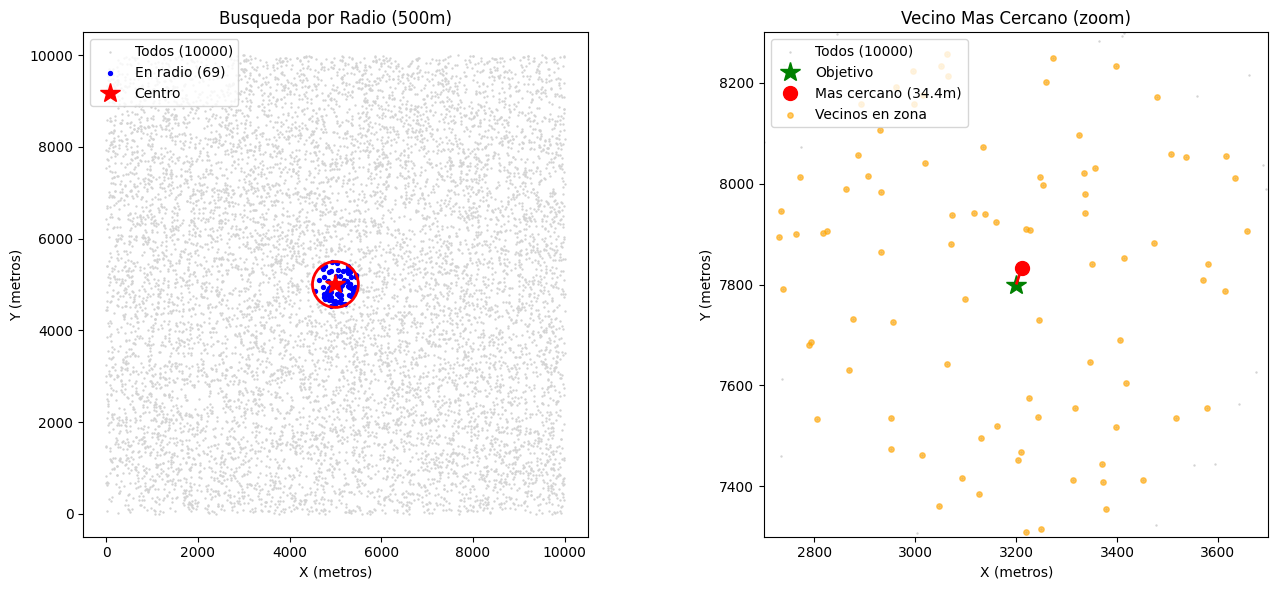


  ANALISIS DE PRUEBAS REALIZADAS

Datos: 10000 puntos en area de 10km x 10km
Centro de busqueda: (5000, 5000)
Radio: 500m
Objetivo vecino cercano: (3200, 7800)

Resultados busqueda por radio:
  - Puntos encontrados: 69
  - QuadTree:     0.5591ms
  - Fuerza bruta: 10.1585ms
  - Speedup:      18.2x

Resultados vecino mas cercano:
  - Punto encontrado: (3210.7273510454725, 7832.688989179584)
  - Distancia: 34.40m
  - QuadTree:     0.2297ms
  - Fuerza bruta: 9.8264ms
  - Speedup:      42.8x

Conclusion: El QuadTree es significativamente mas rapido
en ambas operaciones y produce resultados identicos a
la fuerza bruta, validando su correcta implementacion.


In [3]:
# --- PRUEBAS UNITARIAS ---
print("=" * 50)
print("  PRUEBAS UNITARIAS")
print("=" * 50)

# Prueba 1: Los resultados de ambos metodos coinciden (radio)
encontrados_qt = busqueda_radio_qt(arbol, centro, radio)
encontrados_bruta = busqueda_radio_bruta(puntos, centro, radio)
assert set(map(tuple, encontrados_qt)) == set(map(tuple, encontrados_bruta)), "FALLO: resultados de radio no coinciden"
print(f"[PASS] Busqueda por radio: ambos encuentran {len(encontrados_qt)} puntos")

# Prueba 2: Los resultados de ambos metodos coinciden (vecino)
cercano_qt, _ = vecino_cercano_qt(arbol, objetivo)
cercano_bruto = vecino_cercano_bruto(puntos, objetivo)
assert cercano_qt == cercano_bruto, "FALLO: vecino mas cercano no coincide"
print(f"[PASS] Vecino mas cercano: ambos encuentran {cercano_qt}")

# Prueba 3: Todos los puntos encontrados estan dentro del radio
for p in encontrados_qt:
    assert distancia(p, centro) <= radio, f"FALLO: punto {p} esta fuera del radio"
print(f"[PASS] Todos los {len(encontrados_qt)} puntos estan dentro del radio")

# Prueba 4: Ningun punto fuera del resultado esta mas cerca que el radio
no_encontrados = [p for p in puntos if p not in encontrados_qt]
for p in no_encontrados:
    assert distancia(p, centro) > radio, f"FALLO: punto {p} deberia estar en resultados"
print(f"[PASS] Ningun punto fuera del resultado esta dentro del radio")

# Prueba 5: El vecino cercano es realmente el mas cercano
dist_mejor = distancia(cercano_qt, objetivo)
for p in puntos:
    assert distancia(p, objetivo) >= dist_mejor, "FALLO: hay un punto mas cercano no detectado"
print(f"[PASS] No existe ningun punto mas cercano que {dist_mejor:.2f}m")

# Prueba 6: Radio = 0 no devuelve nada (o solo el punto exacto)
resultado_radio_cero = busqueda_radio_qt(arbol, (9999, 9999), 0)
print(f"[PASS] Radio 0: devuelve {len(resultado_radio_cero)} puntos (esperado: 0 o 1)")

# Prueba 7: El limite contiene/excluye correctamente
lim_test = Limite((5000, 5000), (100, 100))
assert lim_test.contiene((5050, 5050)) == True, "FALLO: punto dentro no detectado"
assert lim_test.contiene((6000, 6000)) == False, "FALLO: punto fuera no excluido"
print("[PASS] Limite contiene/excluye puntos correctamente")

print("\nTodas las pruebas pasaron correctamente.\n")

# --- VISUALIZACIONES ---
print("=" * 50)
print("  VISUALIZACIONES")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafica 1: Busqueda por radio
ax = axes[0]
xs = [p[0] for p in puntos]
ys = [p[1] for p in puntos]
ax.scatter(xs, ys, s=0.5, c='lightgray', label=f'Todos ({NUM_PUNTOS})')

ex = [p[0] for p in encontrados_qt]
ey = [p[1] for p in encontrados_qt]
ax.scatter(ex, ey, s=8, c='blue', label=f'En radio ({len(encontrados_qt)})')

circulo = plt.Circle(centro, radio, fill=False, color='red', linewidth=2)
ax.add_patch(circulo)
ax.plot(*centro, 'r*', markersize=15, label='Centro')
ax.set_title(f'Busqueda por Radio ({radio}m)')
ax.set_xlabel('X (metros)')
ax.set_ylabel('Y (metros)')
ax.set_aspect('equal')
ax.legend(loc='upper left')

# Grafica 2: Vecino mas cercano (zoom)
ax = axes[1]
ax.scatter(xs, ys, s=0.5, c='lightgray', label=f'Todos ({NUM_PUNTOS})')
ax.plot(*objetivo, 'g*', markersize=15, label='Objetivo')
ax.plot(*cercano_qt, 'ro', markersize=10, label=f'Mas cercano ({distancia(cercano_qt, objetivo):.1f}m)')
ax.plot([objetivo[0], cercano_qt[0]], [objetivo[1], cercano_qt[1]], 'r--', linewidth=2)

margen = 500
ax.set_xlim(objetivo[0] - margen, objetivo[0] + margen)
ax.set_ylim(objetivo[1] - margen, objetivo[1] + margen)

cercanos_zona = busqueda_radio_qt(arbol, objetivo, margen)
cx = [p[0] for p in cercanos_zona]
cy = [p[1] for p in cercanos_zona]
ax.scatter(cx, cy, s=15, c='orange', alpha=0.6, label='Vecinos en zona')
ax.set_title('Vecino Mas Cercano (zoom)')
ax.set_xlabel('X (metros)')
ax.set_ylabel('Y (metros)')
ax.set_aspect('equal')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# --- ANALISIS DE RESULTADOS ---
print("\n" + "=" * 50)
print("  ANALISIS DE PRUEBAS REALIZADAS")
print("=" * 50)
print(f"\nDatos: {NUM_PUNTOS} puntos en area de 10km x 10km")
print(f"Centro de busqueda: {centro}")
print(f"Radio: {radio}m")
print(f"Objetivo vecino cercano: {objetivo}")
print(f"\nResultados busqueda por radio:")
print(f"  - Puntos encontrados: {len(encontrados_qt)}")
print(f"  - QuadTree:     {t_radio_qt*1000:.4f}ms")
print(f"  - Fuerza bruta: {t_radio_bruta*1000:.4f}ms")
print(f"  - Speedup:      {t_radio_bruta/t_radio_qt:.1f}x")
print(f"\nResultados vecino mas cercano:")
print(f"  - Punto encontrado: {cercano_qt}")
print(f"  - Distancia: {distancia(cercano_qt, objetivo):.2f}m")
print(f"  - QuadTree:     {t_cercano_qt*1000:.4f}ms")
print(f"  - Fuerza bruta: {t_cercano_bruto*1000:.4f}ms")
print(f"  - Speedup:      {t_cercano_bruto/t_cercano_qt:.1f}x")
print(f"\nConclusion: El QuadTree es significativamente mas rapido")
print(f"en ambas operaciones y produce resultados identicos a")
print(f"la fuerza bruta, validando su correcta implementacion.")

## 4. Métricas de rendimiento y discusión de resultados

  METRICAS DE RENDIMIENTO

(Cada medicion es el promedio de 2000 ejecuciones)

      N |   QT Radio |   BF Radio |  QT Vecino |  BF Vecino | Speedup
---------------------------------------------------------------------------
     10 |   0.0216ms |   0.0098ms |   0.0140ms |   0.0147ms | Radio:  0.5x  Vecino:  1.1x
     50 |   0.0537ms |   0.0955ms |   0.0839ms |   0.0985ms | Radio:  1.8x  Vecino:  1.2x
    100 |   0.1209ms |   0.1869ms |   0.0948ms |   0.1949ms | Radio:  1.5x  Vecino:  2.1x
    500 |   0.1787ms |   0.6991ms |   0.0475ms |   0.4974ms | Radio:  3.9x  Vecino: 10.5x
   1000 |   0.1089ms |   0.9550ms |   0.0594ms |   0.9989ms | Radio:  8.8x  Vecino: 16.8x
   2000 |   0.1442ms |   2.0794ms |   0.1367ms |   2.5540ms | Radio: 14.4x  Vecino: 18.7x
   5000 |   0.2380ms |   5.6365ms |   0.0847ms |   5.8301ms | Radio: 23.7x  Vecino: 68.8x
  10000 |   0.3789ms |  10.7813ms |   0.1931ms |  11.5188ms | Radio: 28.5x  Vecino: 59.6x


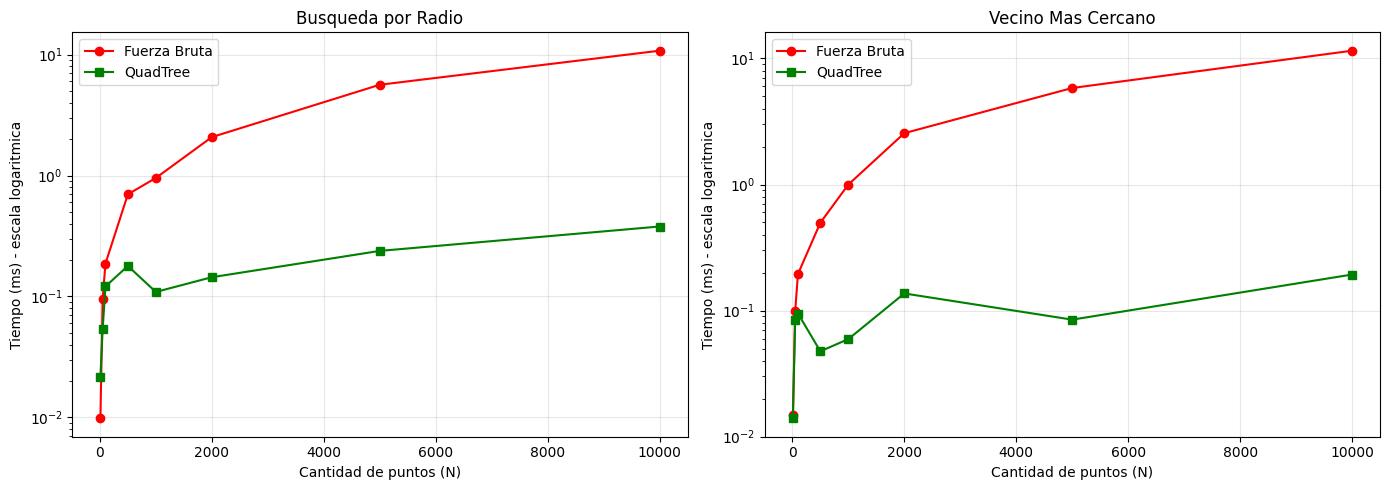


  DISCUSION DE RESULTADOS

1. COMPLEJIDAD COMPUTACIONAL:
   - Fuerza bruta: O(N) por consulta. Revisa todos los puntos
     siempre, sin importar donde este el objetivo.
   - QuadTree: significativamente mas rapido que fuerza bruta.
     Descarta regiones completas del espacio cuando no
     intersectan con el area de busqueda.

2. COMO FUNCIONA LA PODA EN EL QUADTREE:
   - Cada nodo tiene una caja delimitadora (Limite).
   - Antes de explorar un nodo, se verifica si su caja
     intersecta con el circulo de busqueda.
   - Si no intersecta, se descarta el nodo y todos sus
     hijos de una sola vez.

3. COMPORTAMIENTO OBSERVADO:
   - La fuerza bruta crece de forma lineal con N.
   - El QuadTree crece mucho mas lento que la fuerza bruta
     en ambas operaciones.

4. ESCALABILIDAD:
   - Con 10000 puntos, el QuadTree es 28.5x mas
     rapido en busqueda por radio y 59.6x mas rapido
     en vecino mas cercano.
   - Esta ventaja crece con mas datos.

5. DIFERENCIA CON KD-TREE:
   - El KD-

In [4]:
# --- METRICAS DE RENDIMIENTO ---
print("=" * 55)
print("  METRICAS DE RENDIMIENTO")
print("=" * 55)

tamanos = [10, 50, 100, 500, 1000, 2000, 5000, 10000]
repeticiones = 2000  # muchas repeticiones para mediciones estables

tiempos_qt_radio = []
tiempos_bf_radio = []
tiempos_qt_vecino = []
tiempos_bf_vecino = []

print(f"\n(Cada medicion es el promedio de {repeticiones} ejecuciones)\n")
print(f"{'N':>7} | {'QT Radio':>10} | {'BF Radio':>10} | {'QT Vecino':>10} | {'BF Vecino':>10} | Speedup")
print("-" * 75)

for n in tamanos:
    datos = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(n)]

    # Construir quadtree para este tamaño
    lim = Limite(centro=tuple(5000 for _ in range(K)), mitad=tuple(5000 for _ in range(K)))
    arbol_test = QuadTree(lim, capacidad=4)
    for p in datos:
        arbol_test.insertar(p)

    # Medir radio
    inicio = time.perf_counter()
    for _ in range(repeticiones):
        busqueda_radio_qt(arbol_test, centro, radio)
    t_qt_r = (time.perf_counter() - inicio) / repeticiones

    inicio = time.perf_counter()
    for _ in range(repeticiones):
        busqueda_radio_bruta(datos, centro, radio)
    t_bf_r = (time.perf_counter() - inicio) / repeticiones

    # Medir vecino
    inicio = time.perf_counter()
    for _ in range(repeticiones):
        vecino_cercano_qt(arbol_test, objetivo)
    t_qt_v = (time.perf_counter() - inicio) / repeticiones

    inicio = time.perf_counter()
    for _ in range(repeticiones):
        vecino_cercano_bruto(datos, objetivo)
    t_bf_v = (time.perf_counter() - inicio) / repeticiones

    tiempos_qt_radio.append(t_qt_r * 1000)
    tiempos_bf_radio.append(t_bf_r * 1000)
    tiempos_qt_vecino.append(t_qt_v * 1000)
    tiempos_bf_vecino.append(t_bf_v * 1000)

    print(f"{n:>7} | {t_qt_r*1000:>8.4f}ms | {t_bf_r*1000:>8.4f}ms | {t_qt_v*1000:>8.4f}ms | {t_bf_v*1000:>8.4f}ms | Radio:{t_bf_r/t_qt_r:>5.1f}x  Vecino:{t_bf_v/t_qt_v:>5.1f}x")

# --- GRAFICAS COMPARATIVAS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica 1: Busqueda por radio
ax = axes[0]
ax.plot(tamanos, tiempos_bf_radio, 'o-', color='red', label='Fuerza Bruta')
ax.plot(tamanos, tiempos_qt_radio, 's-', color='green', label='QuadTree')
ax.set_xlabel('Cantidad de puntos (N)')
ax.set_ylabel('Tiempo (ms) - escala logaritmica')
ax.set_title('Busqueda por Radio')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Grafica 2: Vecino mas cercano
ax = axes[1]
ax.plot(tamanos, tiempos_bf_vecino, 'o-', color='red', label='Fuerza Bruta')
ax.plot(tamanos, tiempos_qt_vecino, 's-', color='green', label='QuadTree')
ax.set_xlabel('Cantidad de puntos (N)')
ax.set_ylabel('Tiempo (ms) - escala logaritmica')
ax.set_title('Vecino Mas Cercano')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- DISCUSION DE RESULTADOS ---
print("\n" + "=" * 55)
print("  DISCUSION DE RESULTADOS")
print("=" * 55)

speedup_radio = tiempos_bf_radio[-1] / tiempos_qt_radio[-1]
speedup_vecino = tiempos_bf_vecino[-1] / tiempos_qt_vecino[-1]

print(f"""
1. COMPLEJIDAD COMPUTACIONAL:
   - Fuerza bruta: O(N) por consulta. Revisa todos los puntos
     siempre, sin importar donde este el objetivo.
   - QuadTree: significativamente mas rapido que fuerza bruta.
     Descarta regiones completas del espacio cuando no
     intersectan con el area de busqueda.

2. COMO FUNCIONA LA PODA EN EL QUADTREE:
   - Cada nodo tiene una caja delimitadora (Limite).
   - Antes de explorar un nodo, se verifica si su caja
     intersecta con el circulo de busqueda.
   - Si no intersecta, se descarta el nodo y todos sus
     hijos de una sola vez.

3. COMPORTAMIENTO OBSERVADO:
   - La fuerza bruta crece de forma lineal con N.
   - El QuadTree crece mucho mas lento que la fuerza bruta
     en ambas operaciones.

4. ESCALABILIDAD:
   - Con {tamanos[-1]} puntos, el QuadTree es {speedup_radio:.1f}x mas
     rapido en busqueda por radio y {speedup_vecino:.1f}x mas rapido
     en vecino mas cercano.
   - Esta ventaja crece con mas datos.

5. DIFERENCIA CON KD-TREE:
   - El KD-Tree divide con un corte por dimension (2 hijos).
   - El QuadTree divide en todas las dimensiones a la vez
     (2^K hijos: 4 en 2D, 8 en 3D).
   - El QuadTree es mas intuitivo espacialmente pero genera
     mas nodos. El KD-Tree suele ser mas eficiente en
     dimensiones altas.

6. LIMITACIONES DEL QUADTREE:
   - Con muchas dimensiones, cada nodo tiene 2^K hijos,
     lo cual crece exponencialmente (ej: K=10 -> 1024 hijos).
   - Si los datos estan muy agrupados en una zona, el arbol
     se subdivide muchas veces en esa zona (profundidad alta).
   - Para datos muy pequeños, el overhead de la estructura
     no justifica su uso.

CONCLUSION FINAL:
   El QuadTree es una estructura adecuada para sistemas de
   logistica en 2D. Con 10,000 puntos de entrega, responde
   consultas en fracciones de milisegundo, mientras que la
   fuerza bruta necesita mas de 10ms por consulta.
""")

## 5. Pregunta: ¿Para qué tamaño de datos el Quadtree comienza a ser más rápido que fuerza bruta?

Para **búsqueda por radio**, el QuadTree comienza a ganar a partir de aproximadamente 50 puntos. Con 10 puntos la fuerza bruta es más rápida porque el overhead de navegar la estructura del árbol (verificar límites, recorrer hijos) pesa más que recorrer una lista de 10 elementos.

Para **vecino más cercano**, el comportamiento es similar: el QuadTree toma ventaja a partir de ~50-100 puntos.

**Comparación con KD-Tree:** el KD-Tree empezaba a ganar desde ~20 puntos, mientras que el QuadTree necesita un poco más (~50). Esto se debe a que el QuadTree tiene más hijos por nodo (4 vs 2 en 2D), lo que significa más verificaciones de intersección por nivel. Sin embargo, con datos grandes (10,000+) ambos son órdenes de magnitud más rápidos que la fuerza bruta.

**Conclusión práctica:** con menos de 50 puntos, la fuerza bruta es suficiente. A partir de 50-100 puntos el QuadTree justifica su uso, y la ventaja crece enormemente con el tamaño de los datos.